In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import interpolate
from sklearn import preprocessing as p

## Cleaning data

In [2]:
#importing data from Modulair MOD-000681
winddata = pd.read_csv('MOD-00681-2-26data.csv').set_index('timestamp')
winddata.head()

,id,timestamp_local,sn,rh,temp,bin0,bin1,bin2,bin3,bin4,...,no2,o3,pm1_model_id,pm25_model_id,pm10_model_id,co_model_id,no_model_id,no2_model_id,o3_model_id,ws_scalar
timestamp,,,,,,,,,,,,,,,,,,,,,
2025-12-29T13:41:45Z,575936314,2025-12-29T08:41:45Z,MOD-00681,94.9,6.1,0.0,0.0,0.0,0.0,0.0,...,10.497,38.829,NaN,NaN,NaN,14468.0,14493.0,14543.0,14518.0,2.71
2025-12-29T13:40:49Z,575936312,2025-12-29T08:40:49Z,MOD-00681,94.9,6.1,0.0,0.0,0.0,0.0,0.0,...,10.500,39.246,NaN,NaN,NaN,14468.0,14493.0,14543.0,14518.0,3.02
2025-12-29T13:39:47Z,575936317,2025-12-29T08:39:47Z,MOD-00681,94.9,6.1,0.0,0.0,0.0,0.0,0.0,...,10.500,39.246,NaN,NaN,NaN,14468.0,14493.0,14543.0,14518.0,2.92
2025-12-29T13:38:45Z,575936316,2025-12-29T08:38:45Z,MOD-00681,94.9,6.1,0.0,0.0,0.0,0.0,0.0,...,10.500,39.246,NaN,NaN,NaN,14468.0,14493.0,14543.0,14518.0,2.49
2025-12-29T13:37:48Z,575936310,2025-12-29T08:37:48Z,MOD-00681,94.9,6.1,0.0,0.0,0.0,0.0,0.0,...,10.500,39.663,NaN,NaN,NaN,14468.0,14493.0,14543.0,14518.0,1.45


In [3]:
#only columns of interest
COLS_TO_INCLUDE = ['timestamp_local','wd','ws']
winddata = winddata[COLS_TO_INCLUDE]

winddata.head()

,timestamp_local,wd,ws
timestamp,,,
2025-12-29T13:41:45Z,2025-12-29T08:41:45Z,6.7,2.67
2025-12-29T13:40:49Z,2025-12-29T08:40:49Z,7.0,2.90
2025-12-29T13:39:47Z,2025-12-29T08:39:47Z,358.6,2.78
2025-12-29T13:38:45Z,2025-12-29T08:38:45Z,0.8,2.14
2025-12-29T13:37:48Z,2025-12-29T08:37:48Z,10.7,1.32


In [4]:
#removing the UTC time
winddata = winddata.reset_index(drop = True)
winddata.head()

,timestamp_local,wd,ws
0,2025-12-29T08:41:45Z,6.7,2.67
1,2025-12-29T08:40:49Z,7.0,2.90
2,2025-12-29T08:39:47Z,358.6,2.78
3,2025-12-29T08:38:45Z,0.8,2.14
4,2025-12-29T08:37:48Z,10.7,1.32


In [5]:
#converting to datetime
winddata['timestamp_local'] = pd.to_datetime(winddata['timestamp_local'],
                                       format='%Y-%m-%dT%H:%M:%SZ',
                                       exact=False)
winddata.head()

,timestamp_local,wd,ws
0,2025-12-29 08:41:45,6.7,2.67
1,2025-12-29 08:40:49,7.0,2.90
2,2025-12-29 08:39:47,358.6,2.78
3,2025-12-29 08:38:45,0.8,2.14
4,2025-12-29 08:37:48,10.7,1.32


In [6]:
#taking hourly average of df. round to floor of the hour
winddata = winddata.groupby(winddata['timestamp_local'].dt.floor('h')).agg(wd = ('wd','mean'),
                                                                           ws = ('ws','mean')).reset_index()

winddata = winddata.round(decimals = 2)
winddata = winddata.dropna()
winddata

,timestamp_local,wd,ws
0,2025-08-29 04:00:00,200.67,1.21
1,2025-08-29 05:00:00,201.54,0.97
2,2025-08-29 06:00:00,204.24,1.35
3,2025-08-29 07:00:00,220.51,1.60
4,2025-08-29 08:00:00,218.75,1.26
...,...,...,...
2814,2025-12-27 22:00:00,31.01,5.82
2815,2025-12-27 23:00:00,65.39,3.02
2816,2025-12-28 00:00:00,99.95,2.47
2817,2025-12-29 07:00:00,178.54,1.08


In [7]:
ts = pd.read_csv('MOD-000681_timeseries_hourly_scaled.csv').reset_index()
ts.head()

,index,timestamp_local,co,no2,o3,no,bin0,bin1,bin2,bin3,bin4,bin5
0,0,2025-03-31 20:00:00,0.499204,0.656074,0.470705,0.000507,0.115365,0.081614,0.067134,0.079612,0.132287,0.357664
1,1,2025-03-31 21:00:00,0.484861,0.575898,0.476657,0.000703,0.136575,0.142902,0.088733,0.093204,0.147982,0.430657
2,2,2025-03-31 22:00:00,0.426520,0.372281,0.531629,0.000734,0.127144,0.207630,0.101576,0.087379,0.125561,0.328467
3,3,2025-03-31 23:00:00,0.341533,0.208995,0.720238,0.000711,0.062239,0.085679,0.043783,0.036893,0.049327,0.109489
4,4,2025-04-01 00:00:00,0.317863,0.140064,0.748833,0.000698,0.066218,0.075672,0.039113,0.033010,0.047085,0.094891


In [8]:
results = pd.read_csv('681_factor_results.csv')
results.head()

,timestamp_local,Factor 1,Factor 2,Factor 3,Factor 4
0,2025-03-31 20:00:00,0.052060,0.085512,0.099961,0.049997
1,2025-03-31 21:00:00,0.051292,0.073015,0.128371,0.059967
2,2025-03-31 22:00:00,0.054611,0.041815,0.115849,0.068972
3,2025-03-31 23:00:00,0.076346,0.017071,0.039033,0.019863
4,2025-04-01 00:00:00,0.078989,0.006683,0.033827,0.017013


## Merging dataframes

In [9]:
data_1_2 = pd.merge(ts, results, on = 'timestamp_local', how = 'inner')
data_1_2

,index,timestamp_local,co,no2,o3,no,bin0,bin1,bin2,bin3,bin4,bin5,Factor 1,Factor 2,Factor 3,Factor 4
0,0,2025-03-31 20:00:00,0.499204,0.656074,0.470705,0.000507,0.115365,0.081614,0.067134,0.079612,0.132287,0.357664,0.052060,0.085512,0.099961,0.049997
1,1,2025-03-31 21:00:00,0.484861,0.575898,0.476657,0.000703,0.136575,0.142902,0.088733,0.093204,0.147982,0.430657,0.051292,0.073015,0.128371,0.059967
2,2,2025-03-31 22:00:00,0.426520,0.372281,0.531629,0.000734,0.127144,0.207630,0.101576,0.087379,0.125561,0.328467,0.054611,0.041815,0.115849,0.068972
3,3,2025-03-31 23:00:00,0.341533,0.208995,0.720238,0.000711,0.062239,0.085679,0.043783,0.036893,0.049327,0.109489,0.076346,0.017071,0.039033,0.019863
4,4,2025-04-01 00:00:00,0.317863,0.140064,0.748833,0.000698,0.066218,0.075672,0.039113,0.033010,0.047085,0.094891,0.078989,0.006683,0.033827,0.017013
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5879,5879,2025-12-27 20:00:00,0.382941,0.317771,0.489262,0.000540,0.045087,0.024703,0.014011,0.009709,0.011211,0.021898,0.053346,0.037477,0.001067,0.042906
5880,5880,2025-12-27 21:00:00,0.360894,0.414080,0.483543,0.000640,0.047395,0.027205,0.015762,0.011650,0.011211,0.021898,0.052102,0.051065,0.001927,0.034252
5881,5881,2025-12-27 22:00:00,0.330928,0.354681,0.506303,0.000530,0.047435,0.029081,0.014594,0.009709,0.011211,0.021898,0.054168,0.042082,0.002624,0.028372
5882,5882,2025-12-27 23:00:00,0.335099,0.371303,0.492414,0.000581,0.058578,0.034084,0.016929,0.009709,0.011211,0.021898,0.052083,0.044411,0.002656,0.035444


In [10]:
data_1_2['timestamp_local'] = pd.to_datetime(data_1_2['timestamp_local'])

In [11]:
data = pd.merge(data_1_2, winddata, on = 'timestamp_local', how = 'inner')
data

,index,timestamp_local,co,no2,o3,no,bin0,bin1,bin2,bin3,bin4,bin5,Factor 1,Factor 2,Factor 3,Factor 4,wd,ws
0,3567,2025-08-29 04:00:00,0.378807,0.223662,0.597339,0.000678,0.030164,0.020951,0.011675,0.009709,0.011211,0.029197,0.065701,0.022627,0.003340,0.028154,200.67,1.21
1,3568,2025-08-29 05:00:00,0.338893,0.295771,0.568861,0.000517,0.029886,0.015947,0.008757,0.007767,0.011211,0.029197,0.062159,0.033244,0.002798,0.016797,201.54,0.97
2,3569,2025-08-29 06:00:00,0.331121,0.324126,0.576914,0.000497,0.030721,0.016260,0.008757,0.007767,0.008969,0.021898,0.062705,0.037046,0.001097,0.013823,204.24,1.35
3,3570,2025-08-29 07:00:00,0.333959,0.245417,0.532213,0.000601,0.034661,0.020013,0.011092,0.007767,0.013453,0.029197,0.058041,0.026543,0.003688,0.024757,220.51,1.60
4,3571,2025-08-29 08:00:00,0.360411,0.251283,0.506653,0.000617,0.038203,0.021889,0.011675,0.009709,0.013453,0.036496,0.055573,0.027870,0.004885,0.034393,218.75,1.26
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2312,5879,2025-12-27 20:00:00,0.382941,0.317771,0.489262,0.000540,0.045087,0.024703,0.014011,0.009709,0.011211,0.021898,0.053346,0.037477,0.001067,0.042906,23.04,4.79
2313,5880,2025-12-27 21:00:00,0.360894,0.414080,0.483543,0.000640,0.047395,0.027205,0.015762,0.011650,0.011211,0.021898,0.052102,0.051065,0.001927,0.034252,30.04,5.02
2314,5881,2025-12-27 22:00:00,0.330928,0.354681,0.506303,0.000530,0.047435,0.029081,0.014594,0.009709,0.011211,0.021898,0.054168,0.042082,0.002624,0.028372,31.01,5.82
2315,5882,2025-12-27 23:00:00,0.335099,0.371303,0.492414,0.000581,0.058578,0.034084,0.016929,0.009709,0.011211,0.021898,0.052083,0.044411,0.002656,0.035444,65.39,3.02


## Plots

In [12]:
wd_rad = np.radians(np.array(data['wd'])) #deg to rad
ws = np.array(data['ws']) #m/s
Factor1 = np.array(data['Factor 1'])
Factor2 = np.array(data['Factor 2'])
Factor3 = np.array(data['Factor 3'])
Factor4 = np.array(data['Factor 4'])

In [13]:
WD, WS = np.meshgrid(np.linspace(0, 2*np.pi, 36), np.linspace(min(ws), max(ws), 16 ))
Z1 = interpolate.griddata((wd_rad, ws), Factor1, (WD, WS), method='linear')
Z2 = interpolate.griddata((wd_rad, ws), Factor2, (WD, WS), method='linear')
Z3 = interpolate.griddata((wd_rad, ws), Factor3, (WD, WS), method='linear')
Z4 = interpolate.griddata((wd_rad, ws), Factor4, (WD, WS), method='linear')

Z1 = np.nan_to_num(Z1, nan=1e-3)
Z2 = np.nan_to_num(Z2, nan=1e-3)
Z3 = np.nan_to_num(Z3, nan=1e-3)
Z4 = np.nan_to_num(Z4, nan=1e-3)

In [14]:
maxima = [np.max(i) for i in [Z1,Z2,Z3,Z4]]
maxima

[np.float64(0.07405383539853472),
 np.float64(0.09670808070552817),
 np.float64(0.23678624343650798),
 np.float64(0.3924343234597209)]

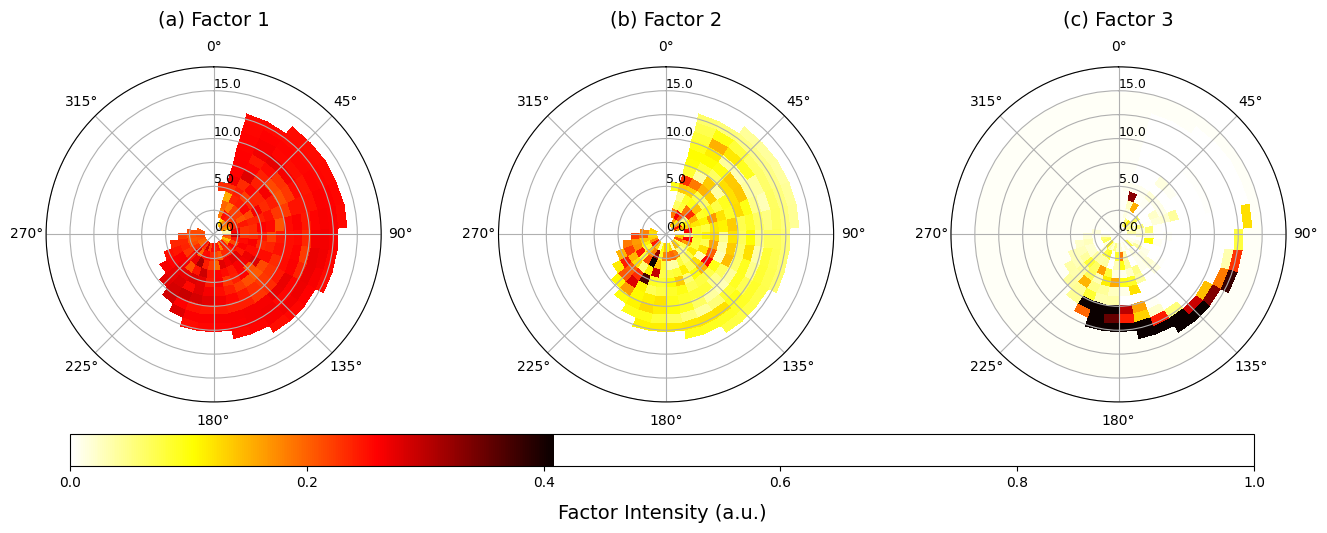

In [15]:
# set up the matplotlib figure
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(16, 16), subplot_kw={'projection': 'polar'})
plt.subplots_adjust(wspace=0.35)
cmap = plt.get_cmap('hot_r')
cmap.set_under('none')

#change set-up to compass bearings
for i in range(3):
    ax[i].set_theta_zero_location('N')
    ax[i].set_theta_direction(-1)

#label
ax[0].set_title('(a) Factor 1',fontsize=14, y=1.10)
ax[1].set_title('(b) Factor 2',fontsize=14, y=1.10)
ax[2].set_title('(c) Factor 3',fontsize=14, y=1.10)

#plot
img1 = ax[0].pcolormesh(WD, WS, Z1, cmap=cmap, vmax = np.max(Z2))
img2 = ax[1].pcolormesh(WD, WS, Z2, cmap=cmap, vmax = np.max(Z2))
img3 = ax[2].pcolormesh(WD, WS, Z3, cmap=cmap, vmax = np.max(Z2))

#label radial ticks
for i in range(3):
    ax[i].tick_params(axis='y', which='major', labelsize=9)
    ax[i].set_rticks([0,2.5,5,7.5,10,12.5,15,17.5])
    ax[i].set_rlabel_position(0)
    ax[i].set_yticklabels(['0.0','','5.0','','10.0','','15.0',''])

#set colorbar
cbar_ax = fig.add_axes([0.14, 0.35, 0.74, 0.02])
cbar = fig.colorbar(img3, cax=cbar_ax, orientation='horizontal')
cbar.set_ticks(list(np.linspace(0, np.max(Z3), 6)))
cbar.set_ticklabels([0.0,0.2,0.4,0.6,0.8,1.0])
cbar.set_label('Factor Intensity (a.u.)', labelpad = 10, fontsize = 14)
cbar.ax.xaxis.set_label_position('bottom')

fig.savefig('windrose_MOD-00681.png')